# Realistic Sources for GWs/FRBs Associations (without redshift information).

Based on [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)].

In [1]:
import sys
sys.path.append('../../Python_scripts')

__Importing modules and constants__

In [2]:
from config import *

__Importing useful support functions__

In [3]:
from support import *

__Importing cosmological functions__

In [4]:
from cosmo_support import *

**Plotting Options**

In [9]:
## Plotting
plt.rcParams['font.family'] ='Times New Roman'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [55]:
SAVE_FIG = True

-------------------------------------

### Main things to add:

- [ ] Generation of GWs events
   1. [ ] Current vs future detectors (rates and observational horizon)
   2. [ ] NS-NS or/and NS-BHs
   3. [ ] Redshift distribution of events
   4. [ ] Realistic luminosity distance posteriors 
   
   <br>

- [ ] Generation of FRB events
   1. [ ] Current vs future detectors (rates and observational horizon)
   2. [ ] Connection to specific GW mechanism?
   4. [ ] Realistic DM posteriors 

# GWs Sources and detections

### 3. Redshift distribution of events

Following [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)] and references therein, we assume a redshift distribution of our GWs events:

$$
P(z) \sim \frac{4 \pi D_c^2(z) R(z)}{H(z)(1+z)},
$$

where $D_c(z)$ is the comoving distance to the source and $R(z)$ denotes the rate of events per redshift, and is given by:

$$
 R(z)  =
  \begin{cases}
            1+2z : z \leq 1 \\
            \frac{3}{4}(5-z) : 1<z<5\\
            0 : z \geq 5
  \end{cases}
$$

In [16]:
redshift_array = np.linspace(0.05, 2, 500)

In [17]:
def Distribution_redshift(z, H0, Omega_m):
    Dc_squared = D_comoving(z, H0, Omega_m)**2
    rate = rate_function(z)
    Hz = Hubble_function(z, H0, Omega_m)
    
    return normalise(4*np.pi*Dc_squared*rate/(Hz*(1+z)))

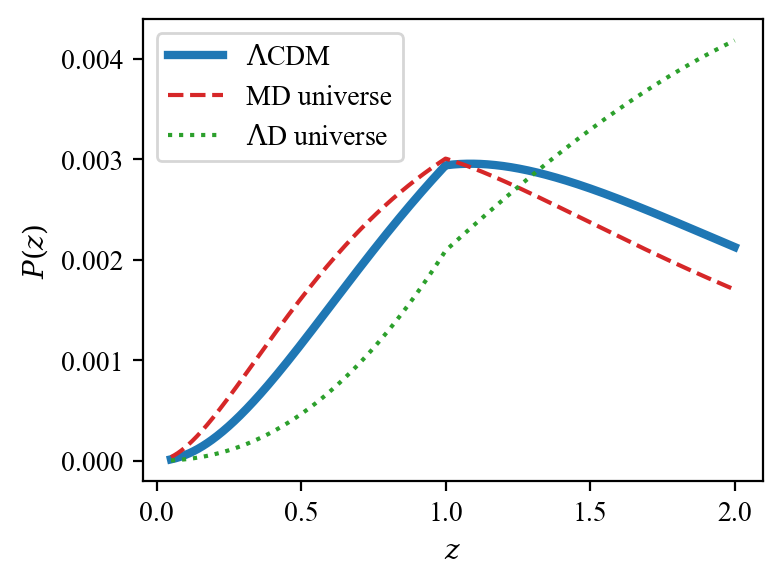

In [21]:
fig = plt.figure(figsize=(4, 3), dpi=200)
ax1 = fig.add_subplot(111)

ax1.plot(redshift_array, Distribution_redshift(redshift_array, HUBBLE, OMEGA_MATTER), label=r'$\Lambda$CDM', c='tab:blue', lw=3)
ax1.plot(redshift_array, Distribution_redshift(redshift_array, HUBBLE, 1), label='MD universe', c='tab:red', ls='--')
ax1.plot(redshift_array, Distribution_redshift(redshift_array, HUBBLE, 0), label=r'$\Lambda$D universe', c='tab:green', ls=':')

ax1.set_ylabel(r'$P(z)$')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left', fontsize=10)

if SAVE_FIG:
    plt.savefig("figures/merger_rate_cosmology.png", dpi=200, bbox_inches='tight')

plt.show()
plt.close()

Draw redshifts that follow the distribution

In [22]:
Pz_array = np.random.choice(redshift_array, size=5000, replace=True,\
                            p=Distribution_redshift(redshift_array, HUBBLE, OMEGA_MATTER))
Uniform_z_array = np.random.choice(redshift_array, size=5000, replace=True)

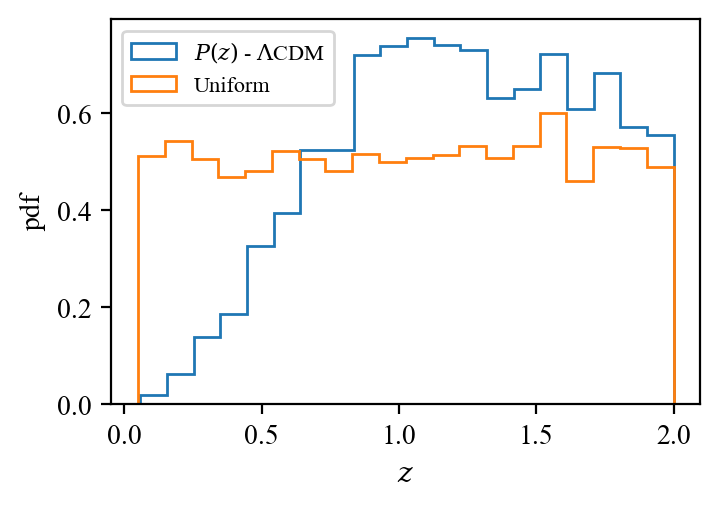

In [39]:
fig = plt.figure(figsize=(3.8, 2.5), dpi=200)
ax1 = fig.add_subplot(111)

NBins = 20

ax1.hist(Pz_array, bins=NBins, density=True, histtype='step', label=r'$P(z)$ - $\Lambda$CDM')
ax1.hist(Uniform_z_array, bins=NBins, density=True, histtype='step', label='Uniform')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel('pdf')
ax1.legend(loc='upper left', fontsize=8)

plt.show()

-------------------------------------

Additional distributions from Jin-Ping Zhu's paper [[2011.02717](https://arxiv.org/abs/2011.02717)].

- The **Gaussian** delay model
- The **LogNormal** delay model
- The **PowerLaw** delay model

In [30]:
def Distribution_redshift_Gaussian(z, epi=-7.553):
    f=(1+z)**(3.879*epi)+((1+z)/73.5)**(-0.4901*epi)+((1+z)/3.672)**(-5.691*epi)+((1+z)/3.411)**(-11.46*epi)+((1+z)/3.546)**(-16.38*epi)+((1+z)/3.716)**(-20.66*epi)
    f=f**(1/epi)
    
    return normalise(f)

def Distribution_redshift_LogNormal(z, epi=-5.51):
    f=(1+z)**(4.131*epi)+((1+z)/22.37)**(-0.5789*epi)+((1+z)/2.978)**(-4.735*epi)+((1+z)/2.749)**(-10.77*epi)+((1+z)/2.867)**(-17.51*epi)+((1+z)/3.04)**(-(0.08148+z**0.574/0.08682)*epi)
    f=f**(1/epi)
    
    return normalise(f)

def Distribution_redshift_Power(z, epi=-8.161):
    f=(1+z)**(1.895*epi)+((1+z)/5.722)**(-3.759*epi)+((1+z)/11.55)**(-0.7426*epi)
    f=f**(1/epi)
    
    return normalise(f)

In [31]:
Pz_gaussian = np.random.choice(redshift_array, size=5000, replace=True,\
                            p=Distribution_redshift_Gaussian(redshift_array))
Pz_LogNormal = np.random.choice(redshift_array, size=5000, replace=True,\
                            p=Distribution_redshift_LogNormal(redshift_array))
Pz_power = np.random.choice(redshift_array, size=5000, replace=True,\
                            p=Distribution_redshift_Power(redshift_array))

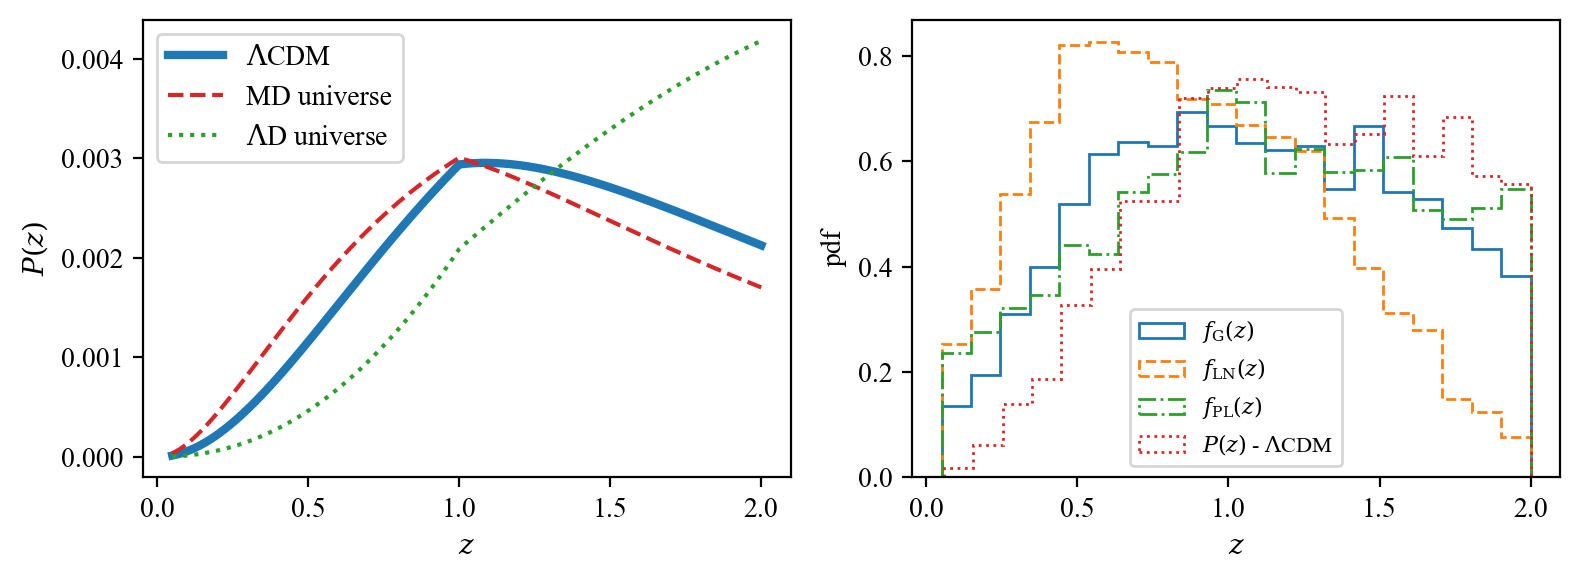

In [56]:
fig = plt.figure(figsize=(8, 3), dpi=200)
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

NBins = 20

ax1.plot(redshift_array, Distribution_redshift(redshift_array, HUBBLE, OMEGA_MATTER), label=r'$\Lambda$CDM', c='tab:blue', lw=3)
ax1.plot(redshift_array, Distribution_redshift(redshift_array, HUBBLE, 1), label='MD universe', c='tab:red', ls='--')
ax1.plot(redshift_array, Distribution_redshift(redshift_array, HUBBLE, 0), label=r'$\Lambda$D universe', c='tab:green', ls=':')

ax1.set_ylabel(r'$P(z)$')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left', fontsize=10)

ax2.hist(Pz_gaussian, bins=NBins, density=True, histtype='step', label=r'$f_{\rm G}(z)$', linestyle='-', lw=2)
ax2.hist(Pz_LogNormal, bins=NBins, density=True, histtype='step', label=r'$f_{\rm LN}(z)$', linestyle='--', lw=2)
ax2.hist(Pz_power, bins=NBins, density=True, histtype='step', label=r'$f_{\rm PL}(z)$', linestyle='-.', lw=2)
ax2.hist(Pz_array, bins=NBins, density=True, histtype='step', label=r'$P(z)$ - $\Lambda$CDM', linestyle=':', lw=4)

ax2.set_xlabel(r'$z$')
ax2.set_ylabel(r'pdf')
ax2.legend(fontsize=8)

plt.tight_layout()


if SAVE_FIG:
    plt.savefig("figures/merger_rate_summary_plot.png", dpi=200, bbox_inches='tight')

plt.show()
plt.close()